# Wstępne przetwarzanie danych

## Dlaczego modele predykcyjne potrzebują czystych danych?

Regresja liniowa wyznacza swoje wyjścia za pomocą wzoru $y = w^T x + b$.

Co w sytuacji, gdy w zbiorze danych pojawią się wartości brakujące? Co się stanie, gdy niektóre wartości w zbiorze danych będą reprezentowane za pomocą tekstu?

**A co w sytuacji, gdy atrybuty zbioru danych będą reprezentowane w różnych skalach?**

Różnice w skali danych bezpośrednio przekładają się na geometrię funkcji kosztu, a ta z kolei naturalnie wpływa na szybkość i stabilność zbieżności algorytmu. Przykładowo:

- $y = w_1 x_1 + w_2 x_2$
- $MSE = \frac{1}{2N} \sum_{i=1}^N \big( (w_1 x_{i,1} + w_2 x_{i,2}) - y_i ^ 2 \big)$

Warto przyjrzeć się, jak różniczkowanie tej funkcji ze względu na poszczególne wagi wpływa na wartości gradientu:
- $\frac{\delta MSE}{\delta w_1} = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i) x_{i, 1}$
- $\frac{\delta MSE}{\delta w_2} = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i) x_{i, 2}$.



Załóżmy, teraz że $x_{i, 1}$ przyjmuje wartości z przedziału $[0,1]$, np. odsetek poprawnych odpowiedzi, a $x_{i, 2}$ - wartości z zakresu $[0, 100000]$, np. miesięczny dochód w PLN. 

W takiej sytuacji:
1. Drobna zmiana wagi w $w_2$ wywołuje ogromną zmianę w wartości przewidywanej $\hat{y}_i$, ponieważ jest mnożona przez $x_2$, której wartość sięga nawet 100000. Funkcja kosztu jest wówczas niezwykle wrażliwa na ruchy wzdłuż osi $x_2$.
2. Zmiana wagi $w_1$ o tę samą wartość ma minimalny wpływ na $\hat{y}$, bo $x_1 \in [0, 1]$. Funkcja kosztu będzie zatem bardzo spłaszczona wzdłuż osi $w_1$.

## Podział danych

Podział danych to krok w potokach uczenia maszynowego polegający na wydzieleniu z oryginalnego zbioru danych przynajmniej dwóch rozłącznych podzbiorów z przeznaczeniem do treningu oraz testu modelu. Dane trenignowe są wykorzystywane tylko i wyłącznie do optymalizacji modelu, a dane testowe (niewidzane podczas treningu) - do oceny zdolności generalizacji modelu. 

### Podział prosty

Do dokonania podziału prostego przeznaczona jest funkcja `train_test_split` znajdująca się w module `model_selection` biblioteki `scikit-learn`.

Warto zauważyć, że istotną wadą podziału prostego jest brak zachowania proporcji względem wybranego atrybutu. Przykładowo, jeżeli w atrybucie decyzyjnym znajdzie się dziesięć zer i dziesięć jedynek, nie mamy kontroli nad tym czy w podzbiorze testowym (o rozmiarze 4) znajdą się same zera, czy dwa zera i dwie jedynki, co jest proporcją zgodną z pełnym oryginalnym zbiorem danym. 

W praktyce jednak, biblioteka `scikit-learn`, zachowuje podobne frakcje ogólnych rozkładów wartości atrybutów w każdym z podzbiorów, jeżeli nie zostanie wskazany konkretny atrybut podziału warstwowego.

In [12]:
from collections import Counter

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [27]:
wine_df = pd.read_csv("data/wine.csv")

In [28]:
wine_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [29]:
wine_train, wine_test = train_test_split(wine_df, test_size=0.2)

In [30]:
[f"{val}: {(count / len(wine_df)) * 100}" for val, count in Counter(wine_df["quality"]).items()]

['5: 42.25721784776903',
 '6: 40.419947506561684',
 '7: 12.510936132983378',
 '4: 2.8871391076115485',
 '8: 1.399825021872266',
 '3: 0.5249343832020997']

In [31]:
[f"{val}: {(count / len(wine_train)) * 100}" for val, count in Counter(wine_train["quality"]).items()]

['5: 41.68490153172866',
 '3: 0.5470459518599562',
 '6: 40.59080962800875',
 '7: 12.910284463894966',
 '4: 3.063457330415755',
 '8: 1.2035010940919038']

In [32]:
[f"{val}: {(count / len(wine_test)) * 100}" for val, count in Counter(wine_test["quality"]).items()]

['6: 39.737991266375545',
 '5: 44.54148471615721',
 '7: 10.91703056768559',
 '8: 2.1834061135371177',
 '4: 2.1834061135371177',
 '3: 0.43668122270742354']

### Podział warstwowy

Podział warstwowy różni się od podziału prostego jedynie jednym aspektem - zachowania oryginalnej frakcji obiektów (według wyznaczonego atrybutu) w każdym z wydzielonych podzbiorów. W przypadku podziału jednej ramki danych, należy wskazać jawnie atrybut, według którego mają zostać zachowane frakcje w podzbiorach. W przypadku podziału `X, y` - takie frakcje zostaną automatycznie wyznaczone na podstawie etykiet `y`.

In [34]:
wine_train, wine_test = train_test_split(wine_df, stratify=wine_df["quality"], test_size=0.2)

In [35]:
[f"{val}: {(count / len(wine_df)) * 100}" for val, count in Counter(wine_df["quality"]).items()]

['5: 42.25721784776903',
 '6: 40.419947506561684',
 '7: 12.510936132983378',
 '4: 2.8871391076115485',
 '8: 1.399825021872266',
 '3: 0.5249343832020997']

In [36]:
[f"{val}: {(count / len(wine_train)) * 100}" for val, count in Counter(wine_train["quality"]).items()]

['6: 40.48140043763676',
 '5: 42.23194748358862',
 '7: 12.472647702407002',
 '4: 2.8446389496717726',
 '3: 0.5470459518599562',
 '8: 1.4223194748358863']

In [37]:
[f"{val}: {(count / len(wine_test)) * 100}" for val, count in Counter(wine_test["quality"]).items()]

['5: 42.35807860262008',
 '6: 40.174672489082965',
 '4: 3.056768558951965',
 '7: 12.663755458515283',
 '3: 0.43668122270742354',
 '8: 1.3100436681222707']

In [38]:
y_col = "quality"
X_cols = list(set(wine_df.columns) - set(y_col))

In [39]:
X = wine_df[X_cols]
y = wine_df[y_col]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [41]:
assert len(X) == len(X_train) + len(X_test)

In [42]:
[f"{val}: {(count / len(y)) * 100}" for val, count in Counter(y).items()]

['5: 42.25721784776903',
 '6: 40.419947506561684',
 '7: 12.510936132983378',
 '4: 2.8871391076115485',
 '8: 1.399825021872266',
 '3: 0.5249343832020997']

In [43]:
[f"{val}: {(count / len(y_train)) * 100}" for val, count in Counter(y_train).items()]

['6: 40.153172866520784',
 '4: 3.282275711159737',
 '7: 12.035010940919037',
 '5: 42.560175054704594',
 '8: 1.4223194748358863',
 '3: 0.5470459518599562']

In [44]:
[f"{val}: {(count / len(y_train)) * 100}" for val, count in Counter(y_train).items()]

['6: 40.153172866520784',
 '4: 3.282275711159737',
 '7: 12.035010940919037',
 '5: 42.560175054704594',
 '8: 1.4223194748358863',
 '3: 0.5470459518599562']

## Obsługa wartości brakujących (oczyszczanie danych)

Wartości brakujące to jedna z częstszych bolączek w uczeniu maszynowym. Modele predykcyjne, zarówno na etapie trenowania jak i wnioskowania, muszą mieć pełną informację na temat przetwarzanych obiektów. W takiej sytuacji dane wybrakowane muszą zostać zredukowane za pomocą całkowitego usunięcia niepełnych obiektów lub atrybutów, bądź wykorzystania technik uzupełniania danych.

Dobór rozwiązania w dużym stopniu zależy od charakteru zbioru danych oraz wartości wybrakowanych. W najbardziej idealnym scenariuszu należy sprawdzić efekt zapewniany przez wszystkie poznane rozwiązania, lecz w przypadku ograniczonych zasobów obliczeniowych może nie zawsze być to osiągalne. W praktyce można spotkać się z intyicyjnymi podejściami, które polegają na usuwaniu wierszy z brakującymi wartościami w przypadku ich niewielkiej liczebności, np. do ok. 0.1% oryginalnego zbioru danych. Podejście na usunięciu całego atrybutu sprawdza się gdy znaczna częśc wartości atrybutu jest wybrakowana. W pozostałych przypadkach najlepiej powinno sprawdzić się uzupełnianie wartości według obranej strategii. Wśród najbardziej typowych strategii uzupełniania wartości wybrakowanych warto wymienić następujące:

- średnia arytmetyczna lub mediana (dla wartości rzeczywistych),
- dominanta (dla danych kategorialnych).

Wśród popularnych podejść można znaleźć także związane z wytrenowanymi predyktorami:
- kNN: dopasowuje brakującą wartość na podstawie najbliższych sąsiadów pozostałych uzupełnionych wartości,
- regresor: dopasowuje brakującą wartość na podstawie modelu regresyjnego wytrenowanego na podstawie uzupełnionych wartości.

Wśród pozostałych metod warto zwrócić także uwagę na kontekst atrybutu, w którym występuje brakująca wartość. Przykładowo, jeżeli wybrakowana wartość dotyczy atrybutu poziomu leukocytów we krwi, warto sprawdzić jakie są normy, a następnie wylosować na podstawie wybranego rozkładu prawdopodobieństwa (np. gaussowskiego) wartość w przedziale stanowiącym normę populacji.

### Oczyszczanie danych z biblioteką pandas

In [45]:
from sklearn.datasets import fetch_california_housing

In [46]:
data = fetch_california_housing(as_frame=True)["frame"]

In [47]:
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


Metoda `isnull` wywołana na obiekcie klasy `Series` zwróci serię wartości logicznych odpowiadających temu czy dana wartość w kolumnie jest wybrakowana.

In [48]:
data["MedInc"].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
20635    False
20636    False
20637    False
20638    False
20639    False
Name: MedInc, Length: 20640, dtype: bool

Za pomocą metody `any` wywołanej na powstałej w ten sposób ramce można sprawdzić czy występuje tam przynajmniej jedna wartość prawdziwa. Metoda `all` umożliwia sprawdzenie czy w ramce występują tylko i wyłącznie wartości prawdziwe.

In [49]:
data["MedInc"].isnull().any()

np.False_

Za pomocą odwołania się do osi kolumn (parametr `axis=0` w metodzie `any`) można z łatwością sprawdzić w których kolumnach występują wartości wybrakowane.

In [50]:
data.isnull().any(axis=0)

MedInc         False
HouseAge       False
AveRooms       False
AveBedrms      False
Population     False
AveOccup       False
Latitude       False
Longitude      False
MedHouseVal    False
dtype: bool

W tym momencie zbiór danych wygląda idealnie - wszystkie obiekty posiadają pełną wiedzę, a wartości wybrakowane nie występują. Pora nieco "popsuć" te dane, czyli usunąć niektóre przypadkowe wartości.

**Ten krok jest tylko dla potrzeb przykładu i w praktyce nigdy nie jest realizowany!**

In [51]:
# przykladowy kod usuwajacy kilka wartosci metoda chybil-trafil
from random import randint

# minimalny i maksymalny odsetek komorek do usuniecia wartosci
min_percent, max_percent = 0.001, 0.003

# wyznacza pseudolosowo od 0.1 do 0.3% komórek z ramki danych
cells_to_remove = randint(int(data.size * min_percent), int(data.size * max_percent))

# pseudolosowy wybor indeksow wierszy i kolumn
for _ in range(cells_to_remove):
    row_idx = randint(0, data.shape[0] - 1)  # pseudolosowy indeks wiersza
    col_idx = randint(0, data.shape[1] - 1)  # pseudolosowy indeks kolumny

    # usuniecie pseudolosowo wskazanej komorki
    data.iat[row_idx, col_idx] = None

Teraz w `data` znajdzie się kilka wartości brakujących

In [52]:
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [53]:
data["MedInc"].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
20635    False
20636    False
20637    False
20638    False
20639    False
Name: MedInc, Length: 20640, dtype: bool

In [54]:
data["MedInc"].isnull().any()

np.True_

In [55]:
data.isnull().any(axis=0)

MedInc         True
HouseAge       True
AveRooms       True
AveBedrms      True
Population     True
AveOccup       True
Latitude       True
Longitude      True
MedHouseVal    True
dtype: bool

Jeżeli w kolumnie występują wartości wybrakowane, można je uzupełnić wskazaną wartością.

In [56]:
data["MedInc"].fillna(0)

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637    1.7000
20638    1.8672
20639    2.3886
Name: MedInc, Length: 20640, dtype: float64

Aby umieścić wartości wybrakowane w oryginalnej ramce danych należy użyć metody `fillna` na obiekcie klasy `DataFrame` przekazując jako parametr słownik mapujący nazwy kolumn na wartości, którymi mają zostać zastąpione wartości wybrakowane.

In [57]:
data.fillna({
    "Longitude": 0,
    "Latitude": 100,
})

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


Biblioteka `pandas` dostarcza metod wyznaczających podstawowe (i bardziej zaawansowane) statystyki. Na szczególną uwagę zasługują metody `mean()` i `median()`, które zwracają odpowiednio średnią arytmetyczną i medianę wartości ze wskazanego atrybutu.

In [58]:
data["MedHouseVal"].mean()

np.float64(2.0686910859333305)

In [59]:
data["MedHouseVal"].median()

np.float64(1.797)

W przypadku wyznaczania dominanty zastosowanie znajduje metoda `mode()`. Należy jednak pamiętać, że dominantą nie zawsze musi być tylko jedna wartość.

In [60]:
data["Population"].mode().iloc[0]

np.float64(891.0)

W takiej sytuacji wypełnienie wartości wybrakowanych ogranicza się do wykorzystania gotowej funkcji, lub wartości tekstowej opisującej agregator: `mean`, `median` lub `mode`.

In [63]:
data["MedInc"].fillna("mean")

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637       1.7
20638    1.8672
20639    2.3886
Name: MedInc, Length: 20640, dtype: object

In [64]:
data["MedInc"].fillna("median")

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637       1.7
20638    1.8672
20639    2.3886
Name: MedInc, Length: 20640, dtype: object

In [65]:
data["MedInc"].fillna("mode")

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637       1.7
20638    1.8672
20639    2.3886
Name: MedInc, Length: 20640, dtype: object

### Oczyszczanie danych z wykorzystaniem biblioteki scikit-learn

Oprócz biblioteki `pandas`, biblioteka `scikit-learn` zawiera także obszerny zestaw narzędzi do pracy z oczyszczaniem danych, w szczególności z uzupełnianiem danych wybrakowanych. Przeznaczona do tego celu klasa `SimpleImputer` przyjmuje w inicjalizatorze parametr strategy, w którym należy wskazać metodę uzupełniania brakujących wartości:
- mean,
- median
- most_frequent,
- constant.

In [66]:
from sklearn.impute import SimpleImputer

In [67]:
imputer = SimpleImputer(strategy="median")

Przed właściwym uzupełnieniem wartości należy najpierw wybrać zestaw pasujących atrybutów, dla których zostanie zastosowana wybrana strategia.

In [ ]:
num_attributes = data.select_dtypes(include=["number"])

In [70]:
num_attributes

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [71]:
num_attributes.isnull().any(axis=0)

MedInc         True
HouseAge       True
AveRooms       True
AveBedrms      True
Population     True
AveOccup       True
Latitude       True
Longitude      True
MedHouseVal    True
dtype: bool

Wywołanie metody `fit` na utworzonym obiekcie pozwoli na automatyczne wyznaczenie wartości do uzupełnienia w każdym z atrybutów.

In [72]:
imputer.fit(num_attributes)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['MedInc','HouseAge','AveRooms',...,'Latitude','Longitude','MedHouseVal']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](9,)","[ 3.53, 29. , 5.23,..., 34.26,-118.49, 1.8 ]"


W atrybucie `statistics_` zawarte są wyznaczone wartości do zastąpenia brakujących według obranej strategii.

In [73]:
imputer.statistics_

array([ 3.53450000e+00,  2.90000000e+01,  5.22987166e+00,  1.04878049e+00,
        1.16600000e+03,  2.81811565e+00,  3.42600000e+01, -1.18490000e+02,
        1.79700000e+00])

Wyjściem metody `transform` nie będzie już ramka danych, lecz tablica `numpy`. Można jednak odwtorzyć z tej postaci formę oryginalną.

In [74]:
new_num_attributes = imputer.transform(num_attributes)

In [75]:
new_num_attributes

array([[   8.3252    ,   41.        ,    6.98412698, ...,   37.88      ,
        -122.23      ,    4.526     ],
       [   8.3014    ,   21.        ,    6.23813708, ...,   37.86      ,
        -122.22      ,    3.585     ],
       [   7.2574    ,   52.        ,    8.28813559, ...,   37.85      ,
        -122.24      ,    3.521     ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,   39.43      ,
        -121.22      ,    0.923     ],
       [   1.8672    ,   18.        ,    5.32951289, ...,   39.43      ,
        -121.32      ,    0.847     ],
       [   2.3886    ,   16.        ,    5.25471698, ...,   39.37      ,
        -121.24      ,    0.894     ]], shape=(20640, 9))

In [76]:
new_num_attributes = pd.DataFrame(new_num_attributes, columns=data.columns)

In [77]:
new_num_attributes

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [78]:
new_num_attributes.isnull().any(axis=0)

MedInc         False
HouseAge       False
AveRooms       False
AveBedrms      False
Population     False
AveOccup       False
Latitude       False
Longitude      False
MedHouseVal    False
dtype: bool

Z uwagi na różnice między interfejsami bibliotek `pandas` i `scikit-learn` warto zwrócić uwagę na typowe aspekty interfejsu aktualnie używanego narzędzia. Wykorzystywane są dwie niezależne metody: `fit` oraz `transform`. Wywołanie metody `fit` oznacza dopasowanie do aktualnie przekazanej ramki danych i wyznaczenie na jej podstawie wartości do uzupełnienia. Analogicznie wygląda sytuacja dla przekazanego atrybutu. Wywołanie metody transform spowoduje faktyczne uzupełnienie brakujących wartości i zwrócenie utworzonego w ten sposób nowego obiektu będącego pełną ramką danych. Warto więc mieć na uwadze, że próba wywołania metody transform po wywołaniu metody fit na innym zbiorze danych może kompletnie mijać się z celem.

## Skalowanie i transformacja wartości

### Transformacja wartości symbolicznych

W zbiorach danych często pojawiają się dane tekstowe (symboliczne) mające charakter kategorialny. Z uwagi na fakt, że algorytmy uczenia maszynowego operują tylko i wyłącznie na wartościach numerycznych, dane tekstowe wymagają przetworzenia do postaci liczbowej. W takiej sytuacji z pomocą przychodzi klasa `OrdinalEncoder` zawarta w module preprocessing biblioteki `scikit-learn`.

In [86]:
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [80]:
data = fetch_kddcup99(as_frame=True)["frame"]

In [81]:
data

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,b'tcp',b'http',b'SF',181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,b'normal.'
1,0,b'tcp',b'http',b'SF',239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,b'normal.'
2,0,b'tcp',b'http',b'SF',235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
3,0,b'tcp',b'http',b'SF',219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
4,0,b'tcp',b'http',b'SF',217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,b'normal.'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,b'tcp',b'http',b'SF',310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.0,0.01,0.0,0.0,b'normal.'
494017,0,b'tcp',b'http',b'SF',282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.0,0.01,0.0,0.0,b'normal.'
494018,0,b'tcp',b'http',b'SF',203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,b'normal.'
494019,0,b'tcp',b'http',b'SF',291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,b'normal.'


Interfejs biblioteki `scikit-learn` umożliwia alternatywne wywoływanie metod `fit` oraz `transform`, które występują po sobie w postaci `fit_transform`.

In [83]:
encoder = OrdinalEncoder()
labels = encoder.fit_transform(data[["protocol_type"]])

In [84]:
labels

array([[1.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]], shape=(494021, 1))

Uzyskane wartości numeryczne przypisane poszczególnym wartościom tekstowym znalazły się w obiekcie `labels`. Uzyskane wartości można z powodzeniem wykorzystać w ramce danych. Klucz, według którego wartości tekstowe były transformowane do wartości numerycznych znajduje się w atrybucie `categories_` obiektu `encoder`, gdzie pozycja tablicy odpowiada przypisanej liczbie.

In [85]:
encoder.categories_

[array([b'icmp', b'tcp', b'udp'], dtype=object)]

Algorytmy uczące się posiadają zdolność do rozpoznawania wzorców definiowalnych przez liczby. W związku z tym niektóre z nich mogą bardziej istotnie traktować wartość liczbową przypisaną protokołowi `UDP` niż protokołowi `ICMP`. W związku z tym warto rozważyć zastosowanie tzw. kodowanie gorącojedynkowe (ang. one-hot encoding), które polega na utworzeniu wektora rzadkiego o rozmiarze n (n = liczba różnych wartości tekstowych) z jedną jedynką na pozycji wskazującej daną kategorię. W tym celu należy wykorzystać klasę `OneHotEncoder`.

In [87]:
encoder = OneHotEncoder()
protocol_onehot = encoder.fit_transform(data[["protocol_type"]])

In [88]:
protocol_onehot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 494021 stored elements and shape (494021, 3)>

Wynikiem jest obiekt zawierający macierz rzadką (ang. sparse matrix), co niesie korzyść w postaci oszczędności pamięci. Za pomocą metody toarray można jednak dokonać transformacji do postaci tablicy `numpy`.

In [89]:
protocol_onehot.toarray()

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], shape=(494021, 3))

Zastąpienie oryginalnego atrybutu wersją gorącojedynkową niesie za sobą zwiększenie ogólnej liczby atrybutów w ramce. Na każdą kategorię powstaje w takiej sytuacji jeden atrybut.

In [90]:
onehot_df = pd.DataFrame(
    protocol_onehot.toarray(),
    columns=encoder.get_feature_names_out(),
    index=data.index,
)

In [91]:
onehot_df

,protocol_type_b'icmp',protocol_type_b'tcp',protocol_type_b'udp'
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
494016,0.0,1.0,0.0
494017,0.0,1.0,0.0
494018,0.0,1.0,0.0
494019,0.0,1.0,0.0


In [92]:
data = data.join(onehot_df)

In [93]:
data

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels,protocol_type_b'icmp',protocol_type_b'tcp',protocol_type_b'udp'
0,0,b'tcp',b'http',b'SF',181,5450,0,0,0,0,...,0.11,0.0,0.0,0.0,0.0,0.0,b'normal.',0.0,1.0,0.0
1,0,b'tcp',b'http',b'SF',239,486,0,0,0,0,...,0.05,0.0,0.0,0.0,0.0,0.0,b'normal.',0.0,1.0,0.0
2,0,b'tcp',b'http',b'SF',235,1337,0,0,0,0,...,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.',0.0,1.0,0.0
3,0,b'tcp',b'http',b'SF',219,1337,0,0,0,0,...,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.',0.0,1.0,0.0
4,0,b'tcp',b'http',b'SF',217,2032,0,0,0,0,...,0.02,0.0,0.0,0.0,0.0,0.0,b'normal.',0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,b'tcp',b'http',b'SF',310,1881,0,0,0,0,...,0.01,0.05,0.0,0.01,0.0,0.0,b'normal.',0.0,1.0,0.0
494017,0,b'tcp',b'http',b'SF',282,2286,0,0,0,0,...,0.17,0.05,0.0,0.01,0.0,0.0,b'normal.',0.0,1.0,0.0
494018,0,b'tcp',b'http',b'SF',203,1200,0,0,0,0,...,0.06,0.05,0.06,0.01,0.0,0.0,b'normal.',0.0,1.0,0.0
494019,0,b'tcp',b'http',b'SF',291,1200,0,0,0,0,...,0.04,0.05,0.04,0.01,0.0,0.0,b'normal.',0.0,1.0,0.0


### Skalowanie i transformacja atrybutów liczbowych

Wiele algorytmów uczących się źle radzi sobie podczas pracy z atrybutami numerycznymi, których wartości mieszczą się w różnych skalach (np. 0-1 oraz 4-290 - znamy już przyczynę). Istnieją jednak metody sprawnie umożliwiające transformację wartości w atrybutach do ujednoliconego zakresu.

Jednym z najpopularniejszych podejść do skalowania atrybutów liczbowych jest **normalizacja** (skalowanie min-max), które polega na umieszczeniu wszystkich wartości w wyznaczonym zakresie (np. 0-1): $x" = \frac{x - min(x)}{max(x) - min(x)}$.

W bibliotece `scikit-learn` do normalizacji służy klasa `MinMaxScaler` zawarta w module `preprocessing`, gdzie można wskazać oczekiwany zakres.

In [98]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [95]:
scaler = MinMaxScaler(feature_range=(-1, 1))
src_bytes_scaled = scaler.fit_transform(data[["src_bytes"]])

In [96]:
src_bytes_scaled

array([[-0.99999948],
       [-0.99999931],
       [-0.99999932],
       ...,
       [-0.99999941],
       [-0.99999916],
       [-0.99999937]], shape=(494021, 1))

In [97]:
src_bytes_scaled.max(), src_bytes_scaled.min()

(np.float64(0.9999999999999998), np.float64(-1.0))

Standaryzacja to proces polegający na wyśrodkowaniu danych oraz zachowaniu wskazanych parametrów dotyczących rozrzutu wartości: $x" = \frac{x - u}{s}$, gdzie:
- $u$ - średnia arytmetyczna,
- $s$ - odchylenie standardowe.

W bibliotece `scikit-learn` do standaryzacji służy klasa `StandardScaler` zawarta w module `preprocessing`.

In [99]:
scaler = StandardScaler()
dst_bytes_scaled = scaler.fit_transform(data[["dst_bytes"]])

In [100]:
dst_bytes_scaled

array([[ 0.13866441],
       [-0.01157787],
       [ 0.01417881],
       ...,
       [ 0.01003232],
       [ 0.01003232],
       [ 0.01106138]], shape=(494021, 1))

Gdzie i kiedy stosować normalizację i standaryzację? Zwykle metody dopasowywane są eksperymentalnie. Warto mieć jednak na uwadze, że stadaryzacja jest czuła na wartości odstające, co może wpływać na różnice w zakresie wartości atrybutów.

### Symetria i normalność atrybutów numerycznych

Wiele algorytmów uczących się posiada założenie, w którym wszystkie atrybuty zbioru danych muszą być dystrybuowane "normalnie", co oznacza że ich wartości pochodzą z rozkładu normalnego. Najprostszą metodą weryfikacji rozkładu atrybutów jest wizualizacja histogramu.

In [118]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [103]:
data = fetch_california_housing(as_frame=True)["frame"]

<Axes: >

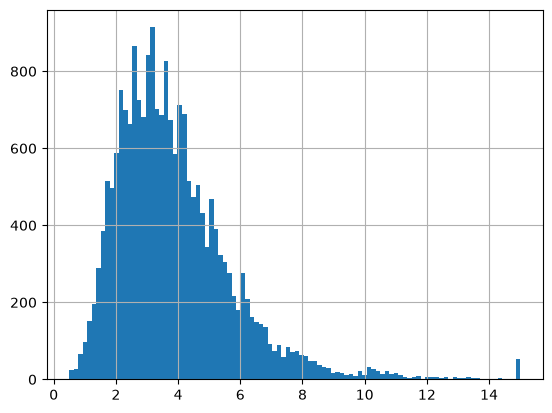

In [104]:
data["MedInc"].hist(bins=100)

Jeżeli powstałe histogramy wykazują cechy asymetrii (jak powyżej - prawoskośny) rozwiązaniem może być wykorzystanie skal transformujących wartości do postaci rozkładu normalnego.

**Skala pierwiastkowa**

<Axes: >

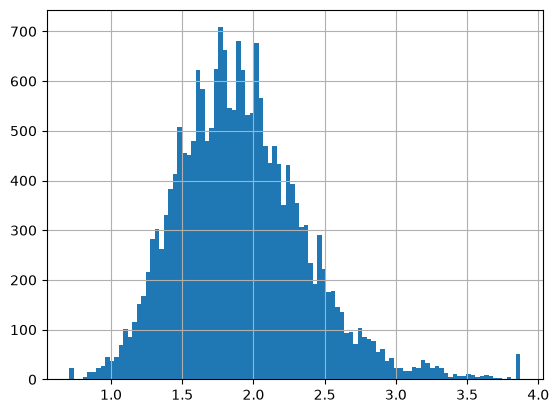

In [106]:
np.sqrt(data["MedInc"]).hist(bins=100)

**Skala logarytmiczna**

<Axes: >

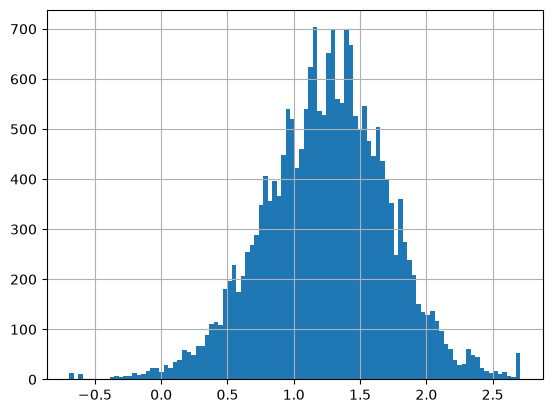

In [107]:
np.log(data["MedInc"]).hist(bins=100)

**Skala inwersyjna**

Skala inwersyjna przypisuje najmniejszej wartości z oryginalnej tablicy wartość największą, a największej – najmniejszą.

$x" = (max_{val} - min_{val}) - x$

In [108]:
values = (data["MedInc"].max() + data["MedInc"].min()) - data["MedInc"]

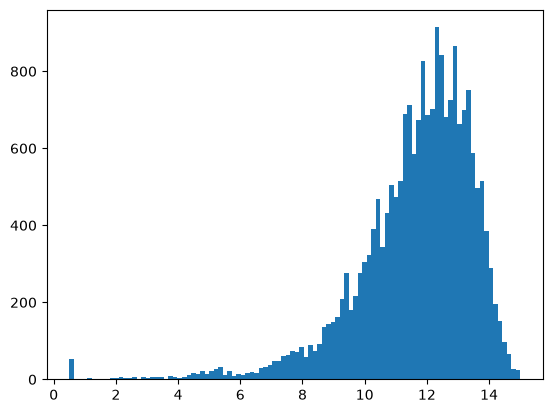

In [111]:
plt.hist(values, bins=100)
plt.show()

**Skala wykładnicza**

<Axes: >

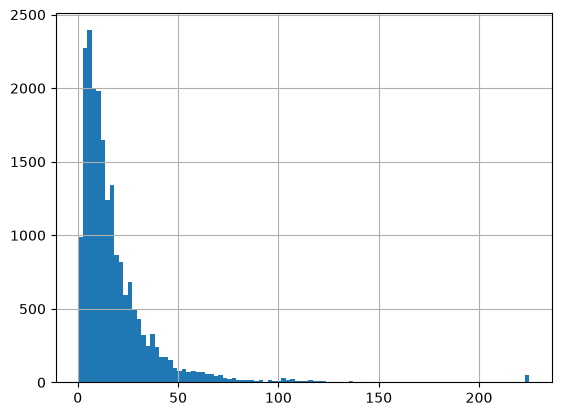

In [116]:

np.pow(data["MedInc"], 2).hist(bins=100)

**Skala Box-Cox**

Skala Box-Cox to rodzina transformacji wykładniczych, zależna od jednego parametry - $\lambda$:
$y^{(\lambda)} = 
\begin{cases}
    \frac{x^{\lambda} - 1}{\lambda} \text{ dla } \lambda \neq 0 \\
    ln(x) \text{ dla } \lambda = 0
\end{cases}
$

W przypadku biblioteki `stats`, wartość parametru $\lambda$ została dobrana automatycznie drogą optymalizacji.

In [119]:
values, _ = stats.boxcox(data["MedInc"])

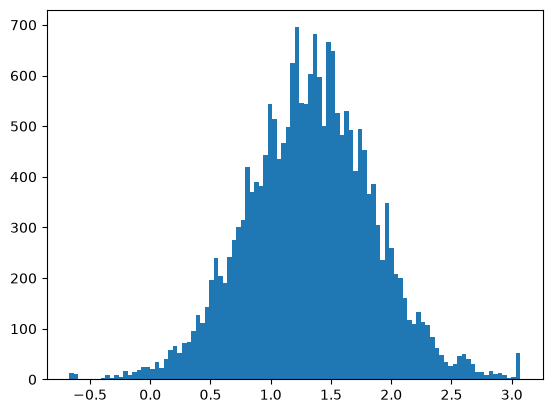

In [120]:
plt.hist(values, bins=100)
plt.show()

**Odwrócona skala wykładnicza**

Odwrócona skala wykładnicza (ang. inverse exponential scale) to transformacja polegająca na połączeniu transformacji wykładniczej z odwróceniem kierunku danych.

In [121]:
b = 0.5

values = np.exp(-b * data["MedInc"])

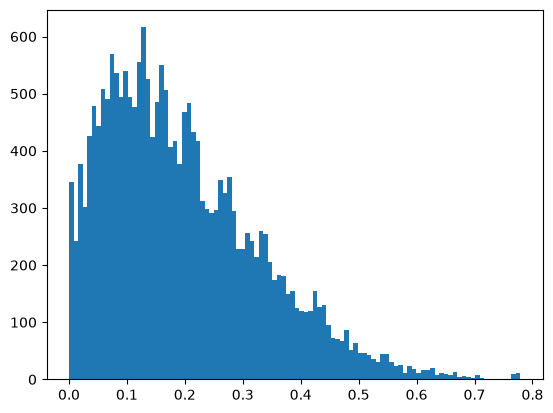

In [122]:
plt.hist(values, bins=100)
plt.show()

## Potoki transformujące

Na podstawie poprzednich materiałów można z łatwością zauważyć, że kolejność wykonania operacji jest niezwykle istotna. W przypadku dużych zbiorów danych, wymagających szeroko zakrojonych operacji transformacji, zapanowanie nad kodem i kolejnością wykonywania operacji może być problematyczne.

Rozwiązaniem problemu są potoki transformujące z biblioteki `scikit-learn`.

Dzięki potokom można z łatwością utrzymywać kod w sposób modularny, co oznacza, że można z łatwością dzielić zadania na mniejsze etapy. Potoki transformujące pomagają unikać zjawiska wycieków informacji z danych treningowych do danych testowych za sprawą izolowania poznanych transformacji do danych treningowych, a następnie stosowanie tych samych transformacji do danych testowych lub walidacyjnych. Zastosowanie takich operacji optymalizujących transformacje wpływają pozytywnie na oszczędność czasu potrzebnego na ogarnięcie dużych fragmentów kodu, a także na walkę z późniejszymi błędami.

#### Stosowanie gotowych transformatorów

Stosowanie potoków transformujących polega na utworzeniu instancji klasy `Pipeline`, której inicjalizator przyjmuje listę zawierającą sprecyzowane kroki przetwarzające dane w postaci krotek: (nazwa, estymator). W znacznej części przypadków wystarczające pozostają klasy (np. `SimpleImputer`) dostarczane przez bibliotekę `scikit-learn`. Warto mieć na uwadze fakt, że estymator musi być klasą która zawiera metody `fit` oraz `transform`.

In [123]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

In [ ]:
num_values_pipeline = Pipeline([
    ("impute_missing_values", SimpleImputer(strategy="mean")),
    ("scale_values", MinMaxScaler()),
])

Alternatywą jest zastosowanie funkcji `make_pipeline`, która przyjmuje dowolną liczbę parametrów w postaci estymatorów. Warto zauważyć, że w tym przypadku nie występuje konieczność przekazania nazw poszczególnych kroków.

In [124]:
from sklearn.pipeline import make_pipeline

In [ ]:
num_values_pipeline = make_pipeline(
    SimpleImputer(strategy="mean"),
    MinMaxScaler(),
)

Zastosowanie potoku na zbiorze danych wymaga wywołania kolejno metod: `fit` i `transform` lub metody `fit_transform`.

In [127]:
num_values_pipeline.fit_transform(data)

array([[0.53966842, 0.78431373, 0.0435123 , ..., 0.5674814 , 0.21115538,
        0.90226638],
       [0.53802706, 0.39215686, 0.03822395, ..., 0.565356  , 0.21215139,
        0.70824656],
       [0.46602805, 1.        , 0.05275646, ..., 0.5642933 , 0.21015936,
        0.69505074],
       ...,
       [0.08276438, 0.31372549, 0.03090386, ..., 0.73219979, 0.31175299,
        0.15938285],
       [0.09429525, 0.33333333, 0.03178269, ..., 0.73219979, 0.30179283,
        0.14371281],
       [0.13025338, 0.29411765, 0.03125246, ..., 0.72582359, 0.30976096,
        0.15340349]], shape=(20640, 9))

In [128]:
data_preprocessed = pd.DataFrame(
    num_values_pipeline.fit_transform(data),
    columns=num_values_pipeline.get_feature_names_out(),
    index=data.index,
)

In [129]:
data_preprocessed

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0.539668,0.784314,0.043512,0.020469,0.008941,0.001499,0.567481,0.211155,0.902266
1,0.538027,0.392157,0.038224,0.018929,0.067210,0.001141,0.565356,0.212151,0.708247
2,0.466028,1.000000,0.052756,0.021940,0.013818,0.001698,0.564293,0.210159,0.695051
3,0.354699,1.000000,0.035241,0.021929,0.015555,0.001493,0.564293,0.209163,0.672783
4,0.230776,1.000000,0.038534,0.022166,0.015752,0.001198,0.564293,0.209163,0.674638
...,...,...,...,...,...,...,...,...,...
20635,0.073130,0.470588,0.029769,0.023715,0.023599,0.001503,0.737513,0.324701,0.130105
20636,0.141853,0.333333,0.037344,0.029124,0.009894,0.001956,0.738576,0.312749,0.128043
20637,0.082764,0.313725,0.030904,0.023323,0.028140,0.001314,0.732200,0.311753,0.159383
20638,0.094295,0.333333,0.031783,0.024859,0.020684,0.001152,0.732200,0.301793,0.143713


#### Potoki dopasowane do typów danych w atrybutach

W przypadku zbiorów danych zawierających różne typy wartości w atrybutach (np. numeryczne i symboliczne), stosowanie potoków uzupełniających wartości wybrakowane za pomocą średniej arytmetycznej może być problematyczne. Rozwiązaniem problemu w takiej sytuacji jest klasa `ColumnTransformer`, która oprócz listy zawierającej nazwe i estymator, przyjmuje także listę nazw atrybutów, na których dany krok ma zostać zastosowany.

In [ ]:
data = fetch_kddcup99(as_frame=True)["frame"]

In [ ]:
data[["duration", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent"]] = data[["duration", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent"]].astype(int)

In [ ]:
data[["protocol_type", "service", "flag", "labels"]] = data[["protocol_type", "service", "flag", "labels"]].map(lambda x: x.decode("utf-8"))

In [134]:
from sklearn.compose import ColumnTransformer

In [ ]:
cat_values_pipeline = make_pipeline(
    OrdinalEncoder(handle_unknown="error"),
)

In [ ]:
preprocessing_pipeline = ColumnTransformer([
    ("num_attributes_steps", num_values_pipeline, data.select_dtypes("number").columns),
    ("cat_attributes_steps", cat_values_pipeline, ("protocol_type", "service", "flag", "labels")),
])

Alternatywnie, jak w przypadku funkcji `make_pipeline`, zastosowanie funkcji `make_column_transformer` pozwoli na pominięcie wskazania nazwy kroku. Wartym uwagi dodatkiem jest funkcja `make_column_selector`, która wybierze atrybuty o wskazanym typie.

In [137]:
from sklearn.compose import make_column_selector, make_column_transformer

In [ ]:
preprocessing_pipeline = make_column_transformer(
    (num_values_pipeline, make_column_selector(dtype_include="number")),
    (cat_values_pipeline, ("protocol_type", "service", "flag", "labels")),
)

In [139]:
data_preprocessed = pd.DataFrame(
    preprocessing_pipeline.fit_transform(data),
    columns=preprocessing_pipeline.get_feature_names_out(),
    index=data.index,
)

In [140]:
data_preprocessed

,pipeline-1__duration,pipeline-1__src_bytes,pipeline-1__dst_bytes,pipeline-1__land,pipeline-1__wrong_fragment,pipeline-1__urgent,pipeline-2__protocol_type,pipeline-2__service,pipeline-2__flag,pipeline-2__labels
0,0.0,2.610418e-07,0.001057,0.0,0.0,0.0,1.0,22.0,9.0,11.0
1,0.0,3.446905e-07,0.000094,0.0,0.0,0.0,1.0,22.0,9.0,11.0
2,0.0,3.389216e-07,0.000259,0.0,0.0,0.0,1.0,22.0,9.0,11.0
3,0.0,3.158461e-07,0.000259,0.0,0.0,0.0,1.0,22.0,9.0,11.0
4,0.0,3.129617e-07,0.000394,0.0,0.0,0.0,1.0,22.0,9.0,11.0
...,...,...,...,...,...,...,...,...,...,...
494016,0.0,4.470881e-07,0.000365,0.0,0.0,0.0,1.0,22.0,9.0,11.0
494017,0.0,4.067060e-07,0.000443,0.0,0.0,0.0,1.0,22.0,9.0,11.0
494018,0.0,2.927706e-07,0.000233,0.0,0.0,0.0,1.0,22.0,9.0,11.0
494019,0.0,4.196859e-07,0.000233,0.0,0.0,0.0,1.0,22.0,9.0,11.0
